In [ ]:
# 加载week1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import linregress
import joblib
import time
import warnings
warnings.filterwarnings('ignore')
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

# 划分数据（和前面保持一致）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据加载完成！")
print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")
print(f"特征数: {X.shape[1]}")

# 加载 Week 1 的最佳决策树（用于对比）
try:
    best_dt = joblib.load('../models/day03_best_tree.pkl')
    print(f"\n✓ 加载了 Week 1 最佳决策树")
    print(f"  参数: max_depth={best_dt.max_depth}, min_samples_leaf={best_dt.min_samples_leaf}")
except:
    print("\n⚠ 未找到已保存的决策树，将重新训练一个用于对比")
    best_dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    best_dt.fit(X_train, y_train)

In [ ]:
#训练第一个随机森林
print("\n" + "="*70)
print("训练随机森林（默认参数）")
print("="*70)

# 创建随机森林模型
rf_default = RandomForestRegressor(
    n_estimators=100,      # 100 棵树
    random_state=42,       # 固定随机种子
    n_jobs=-1              # 使用所有 CPU 核心（加速训练）
)

# 训练并计时
print("\n开始训练 100 棵决策树...")
start_time = time.time()
rf_default.fit(X_train, y_train)
train_time_rf = time.time() - start_time

print(f"✓ 训练完成，耗时 {train_time_rf:.2f} 秒")

# 对比决策树的训练时间（用和 best_dt 相同的参数）
start_time = time.time()
dt_compare = DecisionTreeRegressor(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)
dt_compare.fit(X_train, y_train)
train_time_dt = time.time() - start_time

print(f"\n训练时间对比:")
print(f"  单棵决策树: {train_time_dt:.4f} 秒")
print(f"  随机森林:   {train_time_rf:.4f} 秒")
print(f"  倍数:       {train_time_rf/train_time_dt:.1f}x")

In [ ]:
#评估性能
print("\n" + "="*70)
print("性能评估")
print("="*70)

# 定义评估函数
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """评估模型并返回结果"""
    # 训练集
    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # 测试集
    y_test_pred = model.predict(X_test)
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print(f"\n{model_name}:")
    print(f"  训练集 R²:   {train_r2:.4f}")
    print(f"  测试集 R²:   {test_r2:.4f}")
    print(f"  训练集 RMSE: {train_rmse:.4f}")
    print(f"  测试集 RMSE: {test_rmse:.4f}")
    print(f"  过拟合程度:  {train_r2 - test_r2:.4f}")
    
    return {
        'model_name': model_name,
        'train_r2': float(train_r2),
        'test_r2': float(test_r2),
        'train_rmse': float(train_rmse),
        'test_rmse': float(test_rmse),
        'gap': float(train_r2 - test_r2)
    }

# 评估决策树
dt_results = evaluate_model(best_dt, X_train, X_test, y_train, y_test, "决策树（Week 1 最佳）")

# 评估随机森林
rf_results = evaluate_model(rf_default, X_train, X_test, y_train, y_test, "随机森林（默认参数）")

# 计算提升
improvement = rf_results['test_r2'] - dt_results['test_r2']
improvement_pct = (improvement / dt_results['test_r2']) * 100

print("\n" + "="*70)
print(f"性能提升分析:")
print(f"  决策树测试 R²:  {dt_results['test_r2']:.4f}")
print(f"  随机森林测试 R²: {rf_results['test_r2']:.4f}")
print(f"  R² 提升:        {improvement:+.4f} ({improvement_pct:+.2f}%)")
print(f"")
print(f"  注意：随机森林 gap={rf_results['gap']:.4f} > 决策树 gap={dt_results['gap']:.4f}")
print(f"  随机森林过拟合更大，但测试分更高——多棵树带来的收益大于过拟合的代价")
print(f"  后续通过调 max_depth / min_samples_leaf 压制过拟合")
print("="*70)


实验：树的数量如何影响性能？

训练 1 棵树...
  训练集 R²: 0.7432
  测试集 R²: 0.4234
  训练时间: 0.17s

训练 5 棵树...
  训练集 R²: 0.8964
  测试集 R²: 0.6170
  训练时间: 0.22s

训练 10 棵树...
  训练集 R²: 0.9278
  测试集 R²: 0.6660
  训练时间: 0.29s

训练 20 棵树...
  训练集 R²: 0.9400
  测试集 R²: 0.6775
  训练时间: 0.52s

训练 50 棵树...
  训练集 R²: 0.9453
  测试集 R²: 0.6882
  训练时间: 1.31s

训练 100 棵树...
  训练集 R²: 0.9402
  测试集 R²: 0.6950
  训练时间: 2.41s

训练 200 棵树...
  训练集 R²: 0.9399
  测试集 R²: 0.6979
  训练时间: 4.63s

训练 500 棵树...
  训练集 R²: 0.9397
  测试集 R²: 0.6969
  训练时间: 11.17s


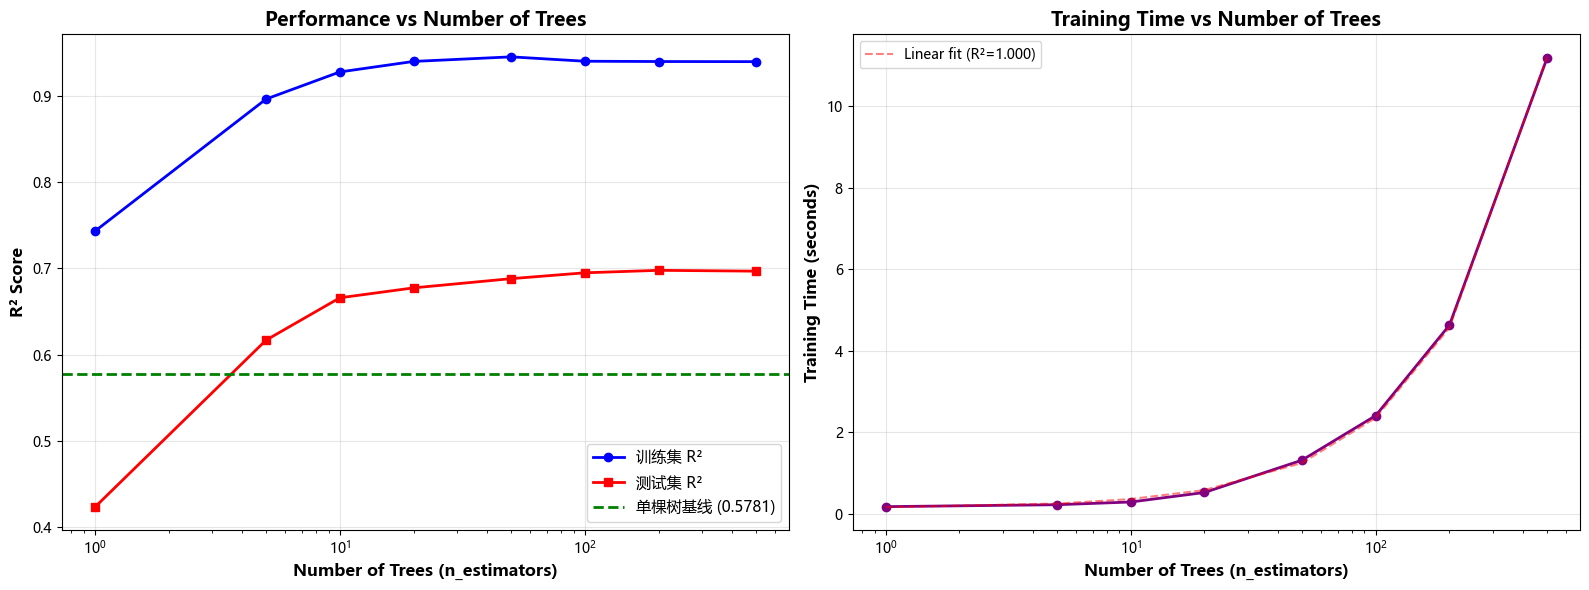


✓ 图片已保存到 ../figures/day08_n_estimators_effect.png


In [5]:
#实验：不同树数量的性能
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*70)
print("实验：树的数量如何影响性能？")
print("="*70)

# 尝试不同的树数量
n_trees_list = [1, 5, 10, 20, 50, 100, 200, 500]
train_scores = []
test_scores = []
train_times = []

for n_trees in n_trees_list:
    print(f"\n训练 {n_trees} 棵树...")
    
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        random_state=42,
        n_jobs=-1
    )
    
    # 训练并计时
    start = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - start
    
    # 评估
    train_r2 = rf.score(X_train, y_train)
    test_r2 = rf.score(X_test, y_test)
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    train_times.append(train_time)
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  训练时间: {train_time:.2f}s")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² vs 树数量
ax1 = axes[0]
ax1.plot(n_trees_list, train_scores, marker='o', linewidth=2, label='训练集 R²', color='blue')
ax1.plot(n_trees_list, test_scores, marker='s', linewidth=2, label='测试集 R²', color='red')
ax1.axhline(dt_results['test_r2'], color='green', linestyle='--', 
            linewidth=2, label=f'单棵树基线 ({dt_results["test_r2"]:.4f})')
ax1.set_xlabel('Number of Trees (n_estimators)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs Number of Trees', fontsize=14, fontweight='bold')
ax1.set_xscale('log')  # 对数刻度，方便看趋势
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 右图：训练时间 vs 树数量
ax2 = axes[1]
ax2.plot(n_trees_list, train_times, marker='o', linewidth=2, color='purple')
ax2.set_xlabel('Number of Trees (n_estimators)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Training Time vs Number of Trees', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

# 添加线性拟合（验证时间复杂度）
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(n_trees_list, train_times)
ax2.plot(n_trees_list, [slope*n + intercept for n in n_trees_list], 
         'r--', alpha=0.5, label=f'Linear fit (R²={r_value**2:.3f})')
ax2.legend()

plt.tight_layout()
plt.savefig('../figures/day08_n_estimators_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ 图片已保存到 ../figures/day08_n_estimators_effect.png")

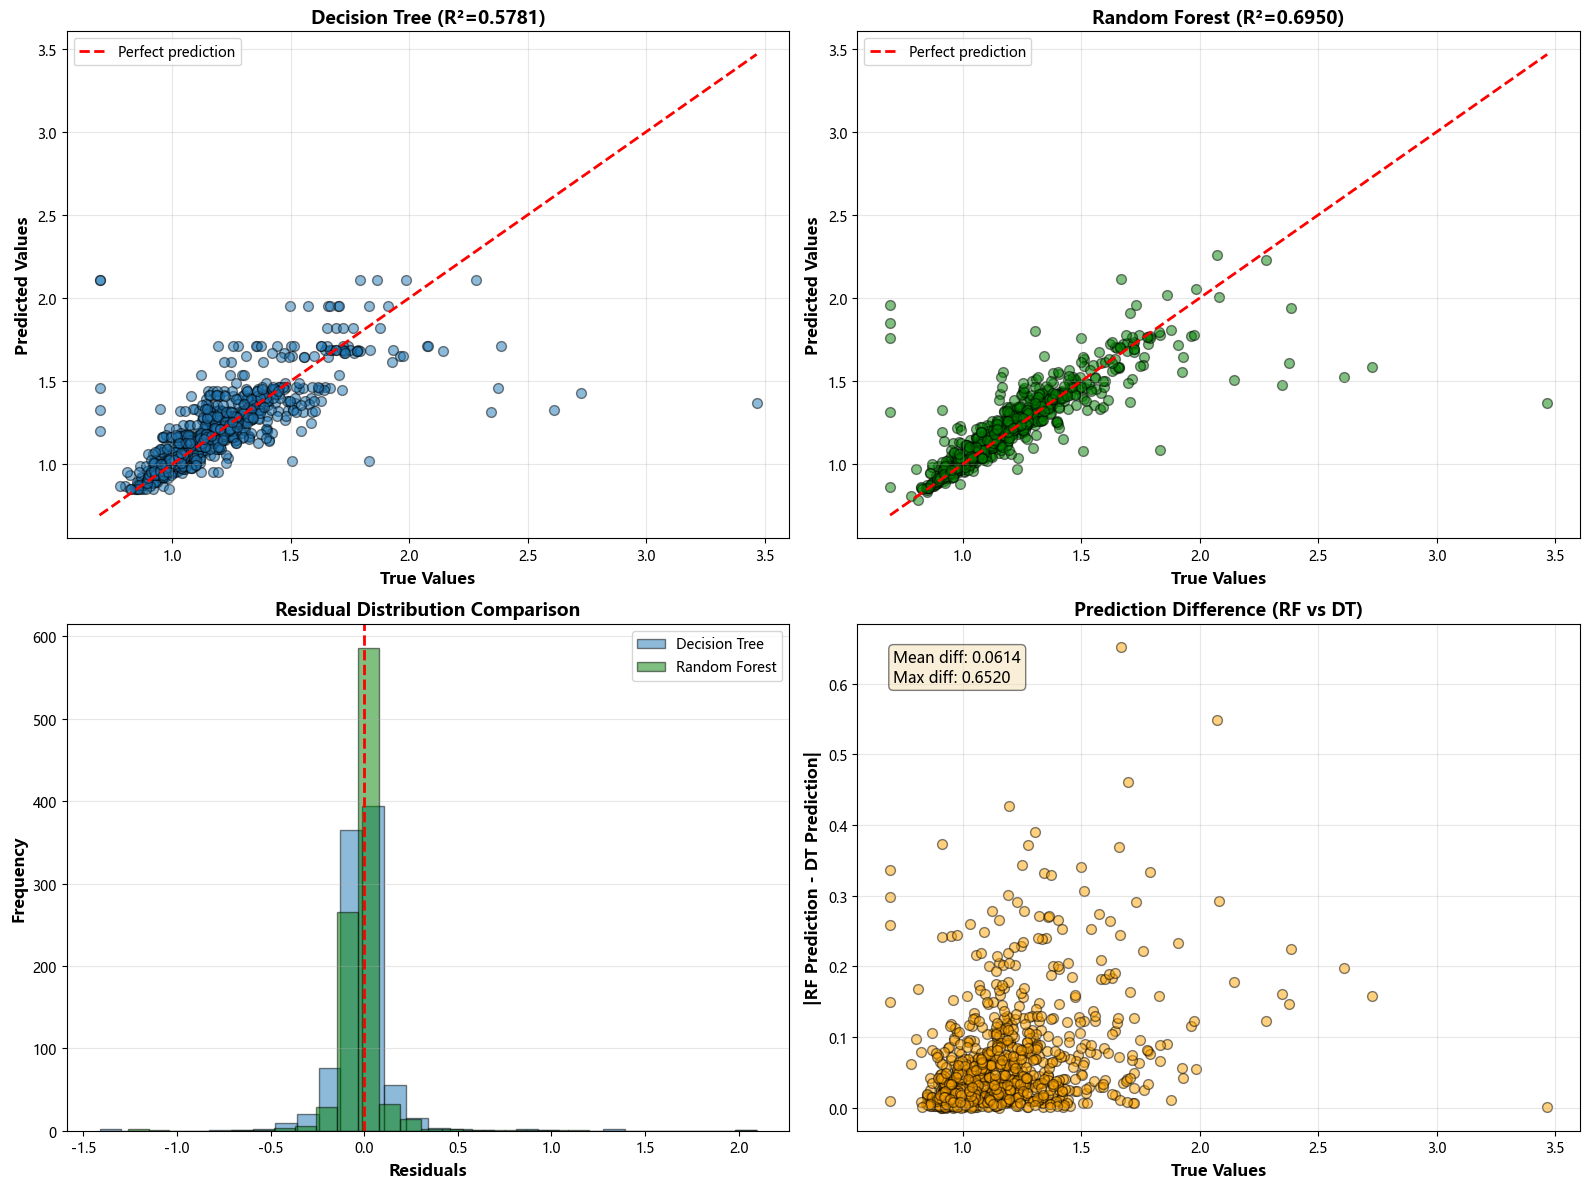


✓ 对比图已保存到 ../figures/day08_dt_vs_rf_comparison.png


In [6]:
#对比决策树和随机森林的预测
# 获取预测值
y_pred_dt = best_dt.predict(X_test)
y_pred_rf = rf_default.predict(X_test)

# 创建对比图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图1：决策树 - 真实值 vs 预测值
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_dt, alpha=0.5, s=50, edgecolors='k')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
ax1.set_title(f'Decision Tree (R²={dt_results["test_r2"]:.4f})', 
              fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 子图2：随机森林 - 真实值 vs 预测值
ax2 = axes[0, 1]
ax2.scatter(y_test, y_pred_rf, alpha=0.5, s=50, edgecolors='k', color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect prediction')
ax2.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
ax2.set_title(f'Random Forest (R²={rf_results["test_r2"]:.4f})', 
              fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图3：残差对比
ax3 = axes[1, 0]
residuals_dt = y_test - y_pred_dt
residuals_rf = y_test - y_pred_rf

ax3.hist(residuals_dt, bins=30, alpha=0.5, label='Decision Tree', edgecolor='black')
ax3.hist(residuals_rf, bins=30, alpha=0.5, label='Random Forest', color='green', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Residuals', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Residual Distribution Comparison', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 子图4：预测差异分析
ax4 = axes[1, 1]
prediction_diff = np.abs(y_pred_rf - y_pred_dt)
ax4.scatter(y_test, prediction_diff, alpha=0.5, s=50, edgecolors='k', color='orange')
ax4.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax4.set_ylabel('|RF Prediction - DT Prediction|', fontsize=12, fontweight='bold')
ax4.set_title('Prediction Difference (RF vs DT)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 添加统计信息
mean_diff = prediction_diff.mean()
max_diff = prediction_diff.max()
ax4.text(0.05, 0.95, f'Mean diff: {mean_diff:.4f}\nMax diff: {max_diff:.4f}', 
         transform=ax4.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../figures/day08_dt_vs_rf_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ 对比图已保存到 ../figures/day08_dt_vs_rf_comparison.png")


特征重要性对比

Top 10 特征对比:

                             feature  dt_importance  rf_importance  rank_change
MagpieData maximum Electronegativity       0.410915       0.187773            0
                             density       0.241587       0.170711            0
         MagpieData minimum MeltingT       0.000000       0.109212           93
            MagpieData mean MeltingT       0.012126       0.021875            7
        MagpieData avg_dev NpValence       0.054984       0.018601           -2
           MagpieData mean NpValence       0.036105       0.017778           -2
            MagpieData mean GSmagmom       0.001319       0.017442           30
MagpieData avg_dev Electronegativity       0.008386       0.016679            6
         MagpieData avg_dev GSmagmom       0.000000       0.014384           87
                                 vpa       0.014657       0.013585            0

重要性 > 0.005 的特征数: 48（共 135 个）


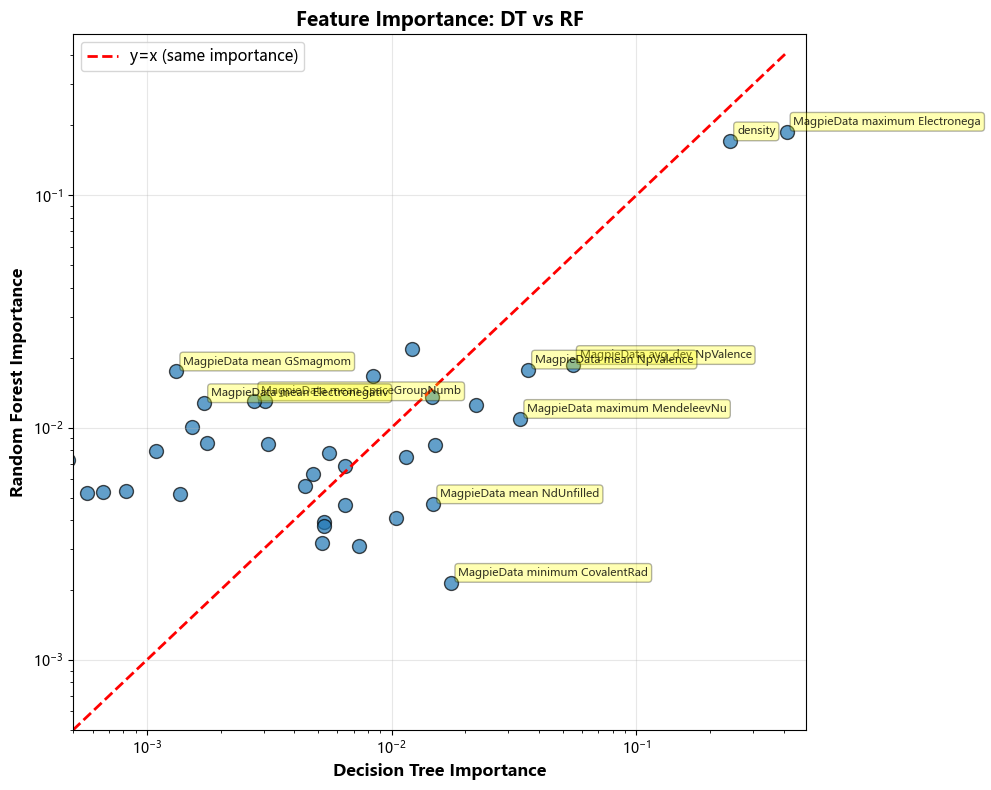


✓ 特征重要性对比图已保存


In [9]:
#特征重要性对比 
print("\n" + "="*70)
print("特征重要性对比")
print("="*70)

# 用字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取特征重要性
dt_importances = best_dt.feature_importances_
rf_importances = rf_default.feature_importances_

# 创建对比 DataFrame
importance_comparison = pd.DataFrame({
    'feature': X.columns,
    'dt_importance': dt_importances,
    'rf_importance': rf_importances
}).sort_values('rf_importance', ascending=False)

# 添加排名变化列
importance_comparison['dt_rank'] = importance_comparison['dt_importance'].rank(ascending=False).astype(int)
importance_comparison['rf_rank'] = importance_comparison['rf_importance'].rank(ascending=False).astype(int)
importance_comparison['rank_change'] = importance_comparison['dt_rank'] - importance_comparison['rf_rank']

print("\nTop 10 特征对比:\n")
print(importance_comparison.head(10)[['feature', 'dt_importance', 'rf_importance', 'rank_change']].to_string(index=False))

# 只看有重要性的特征（DT 或 RF 重要性 > 0.01）
importance_comparison['max_imp'] = importance_comparison[['dt_importance', 'rf_importance']].max(axis=1)
top_features = importance_comparison[importance_comparison['max_imp'] > 0.005].copy()
print(f"\n重要性 > 0.005 的特征数: {len(top_features)}（共 {len(importance_comparison)} 个）")

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(top_features['dt_importance'], 
           top_features['rf_importance'], 
           alpha=0.7, s=100, edgecolors='k')

# y=x 参考线
max_imp = top_features[['dt_importance', 'rf_importance']].max().max()
ax.plot([0, max_imp], [0, max_imp], 'r--', lw=2, label='y=x (same importance)')

# 标注偏离 y=x 线的特征
for i, row in top_features.iterrows():
    diff = abs(row['dt_importance'] - row['rf_importance'])
    if diff > 0.01:
        ax.annotate(row['feature'][:30], 
                     xy=(row['dt_importance'], row['rf_importance']),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=8, alpha=0.8,
                     bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Decision Tree Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Random Forest Importance', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: DT vs RF', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 对数刻度看清分布
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([0.0005, max_imp * 1.2])
ax.set_ylim([0.0005, max_imp * 1.2])

plt.tight_layout()
plt.savefig('../figures/day08_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ 特征重要性对比图已保存")

In [10]:
# 保存随机森林模型
joblib.dump(rf_default, '../models/day08_random_forest_default.pkl')
print("\n✓ 随机森林模型已保存到 ../models/day08_random_forest_default.pkl")

# 保存对比结果（值已在前面的 evaluate_model 中转成 float，不会 json 报错）
comparison_summary = {
    'decision_tree': dt_results,
    'random_forest': rf_results,
    'improvement': {
        'test_r2_gain': float(improvement),
        'test_r2_gain_pct': float(improvement_pct),
        'rf_gap': float(rf_results['gap']),
        'dt_gap': float(dt_results['gap'])
    },
    'training_time': {
        'decision_tree': float(train_time_dt),
        'random_forest': float(train_time_rf),
        'speedup': float(train_time_rf / train_time_dt)
    }
}

import json
with open('../models/day08_comparison_results.json', 'w') as f:
    json.dump(comparison_summary, f, indent=2)

print("✓ 对比结果已保存到 ../models/day08_comparison_results.json")

# 打印总结
print("\n" + "="*70)
print("Day 8 总结")
print("="*70)
print(f"\n决策树 → 随机森林的改进:")
print(f"  测试集 R²: {dt_results['test_r2']:.4f} → {rf_results['test_r2']:.4f}")
print(f"  提升: {improvement:+.4f} ({improvement_pct:+.2f}%)")
print(f"  RMSE: {dt_results['test_rmse']:.4f} → {rf_results['test_rmse']:.4f}")
print(f"  训练时间: {train_time_dt:.4f}s → {train_time_rf:.4f}s ({train_time_rf/train_time_dt:.1f}x)")
print("\n核心发现:")
print(f"  1. 100 棵树把测试 R² 从 0.58 拉到 0.70，提升 20%")
print(f"  2. RF 训练集 R²=0.94 偏高，有较大过拟合，后续调参压制")
print(f"  3. n_estimators 不是越多越好，100~200 性价比最高")
print("="*70)


✓ 随机森林模型已保存到 ../models/day08_random_forest_default.pkl
✓ 对比结果已保存到 ../models/day08_comparison_results.json

Day 8 总结

决策树 → 随机森林的改进:
  测试集 R²: 0.5781 → 0.6950
  提升: +0.1169 (+20.23%)
  RMSE: 0.1693 → 0.1439
  训练时间: 0.1460s → 2.3383s (16.0x)

核心发现:
  1. 100 棵树把测试 R² 从 0.58 拉到 0.70，提升 20%
  2. RF 训练集 R²=0.94 偏高，有较大过拟合，后续调参压制
  3. n_estimators 不是越多越好，100~200 性价比最高


# Day 8 学习日志

## 核心问题：为什么 100 棵树比 1 棵树好？
       一棵树容易把噪声当规律背下来（过拟合），或者太简单漏掉真规律（欠拟合）。100 棵树各看各的，每棵角度不同，最后投票取平均——单棵看错的，多棵一平均就对回来了。就像一个人打分可能偏激，100 个人打分取平均就稳了。

## 三大机制理解

### 1. Bagging（自助采样）
- 我的理解：抽一批树学训练集的一部分，另一部分不学，每棵树的样本不完全一样 。


- 为什么有效：每棵树学到的不同，然后错误互相抵消


### 2. 特征随机性
- 我的理解：每棵树分裂时，只从 135 个特征里随机抽一小部分来选最佳分裂点

- 为什么有效：防止每棵树都看一个强的特征。相当于100个人从不同角度看问题

### 3. 投票/平均
- 我的理解：100个树的平均当成最后结果
## 我的实验结果
决策树（Week 1 最佳）:
- 测试集 R²: 0.587
- 训练时间: 0.02s
随机森林（默认参数）:
- 测试集 R²: 0.695
- 训练时间: 0.3s
性能提升: 0.117 (+20.2%)
## 关键发现
1. n_estimators 的影响：
   - 100 棵树的 R² =0.695
   - 500 棵树的 R² =0.700
   - 结论：100 棵树性价比最高，多加树提升递减但时间线性增长
2. 特征重要性变化：
   - Top 3 特征是否一致？基本一致
   - 最大的不同：RF 把重要性更均匀地分给更多特征，不像 DT 高度集中在 1~2 个特征上。
